In [9]:
# Celda 1: Librerías y conexión a MongoDB
import pymongo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["taller4_db"]
col = db["raw_data"]

print(f"✅ Conectado. Documentos en raw_data: {col.count_documents({})}")

✅ Conectado. Documentos en raw_data: 931


In [10]:
# Celda 2: Leer MongoDB y seleccionar 5 variables relevantes
cursor = col.find({}, {
    "name":         1,
    "brand":        1,
    "price":        1,
    "rating":       1,
    "product_type": 1,
    "_id":          0
})

df = pd.DataFrame(list(cursor))
df["price"]  = pd.to_numeric(df["price"],  errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

print(f"Shape del DataFrame: {df.shape}")
df.head(10)

Shape del DataFrame: (931, 5)


,brand,name,price,rating,product_type
0,rejuva minerals,Multi Purpose Powder - Blush & Eye,0.0,NaN,blush
1,marienatie,Mineral Blush,0.0,NaN,blush
2,lotus cosmetics usa,Creme to Powder Blush,0.0,NaN,blush
3,glossier,Cloud Paint,22.0,NaN,blush
4,nyx,Sweet Cheeks Blush Palette,20.0,NaN,blush
5,nyx,Cheek Contour Duo Palette,9.0,NaN,blush
6,nyx,High Definition Blush Pro Refills,6.0,NaN,blush
7,nyx,Rouge Cream Blush,6.0,NaN,blush
8,nyx,Baked Blush,7.0,NaN,blush
9,nyx,High Definition Blush,6.5,NaN,blush


In [11]:
# Celda 3: Inspección básica del DataFrame
print("=== PRIMERAS FILAS ===")
display(df.head())

print("\n=== TIPOS DE DATOS ===")
df.info()

print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
display(df.describe())

=== PRIMERAS FILAS ===


,brand,name,price,rating,product_type
0,rejuva minerals,Multi Purpose Powder - Blush & Eye,0.0,NaN,blush
1,marienatie,Mineral Blush,0.0,NaN,blush
2,lotus cosmetics usa,Creme to Powder Blush,0.0,NaN,blush
3,glossier,Cloud Paint,22.0,NaN,blush
4,nyx,Sweet Cheeks Blush Palette,20.0,NaN,blush



=== TIPOS DE DATOS ===
<class 'pandas.DataFrame'>
RangeIndex: 931 entries, 0 to 930
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         919 non-null    str    
 1   name          931 non-null    str    
 2   price         917 non-null    float64
 3   rating        340 non-null    float64
 4   product_type  931 non-null    str    
dtypes: float64(2), str(3)
memory usage: 36.5 KB

=== VALORES NULOS ===
brand            12
name              0
price            14
rating          591
product_type      0
dtype: int64

=== ESTADÍSTICAS DESCRIPTIVAS ===


,price,rating
count,917.000000,340.000000
mean,16.508593,4.319118
std,11.028035,0.675849
min,0.000000,1.500000
25%,8.990000,4.000000
50%,13.990000,4.500000
75%,22.000000,5.000000
max,77.000000,5.000000


In [12]:
# Celda 4: 5 Insights relevantes de los datos
precio_prom = df["price"].mean()
marca_top   = df["brand"].value_counts().idxmax()
marca_count = df["brand"].value_counts().max()
tipo_top    = df["product_type"].value_counts().idxmax()
rating_prom = df["rating"].mean()
prod_caro   = df.loc[df["price"].idxmax(), "name"]
precio_max  = df["price"].max()

print(f"1. 💰 Precio promedio: ${precio_prom:.2f}")
print(f"2. 🏆 Marca con más productos: '{marca_top}' con {marca_count} productos")
print(f"3. 💄 Tipo más frecuente: '{tipo_top}'")
print(f"4. ⭐ Rating promedio: {rating_prom:.2f} / 5.0")
print(f"5. 💎 Producto más caro: '{prod_caro}' a ${precio_max:.2f}")

1. 💰 Precio promedio: $16.51
2. 🏆 Marca con más productos: 'nyx' con 164 productos
3. 💄 Tipo más frecuente: 'foundation'
4. ⭐ Rating promedio: 4.32 / 5.0
5. 💎 Producto más caro: 'Dior Holiday Couture Collection' a $77.00


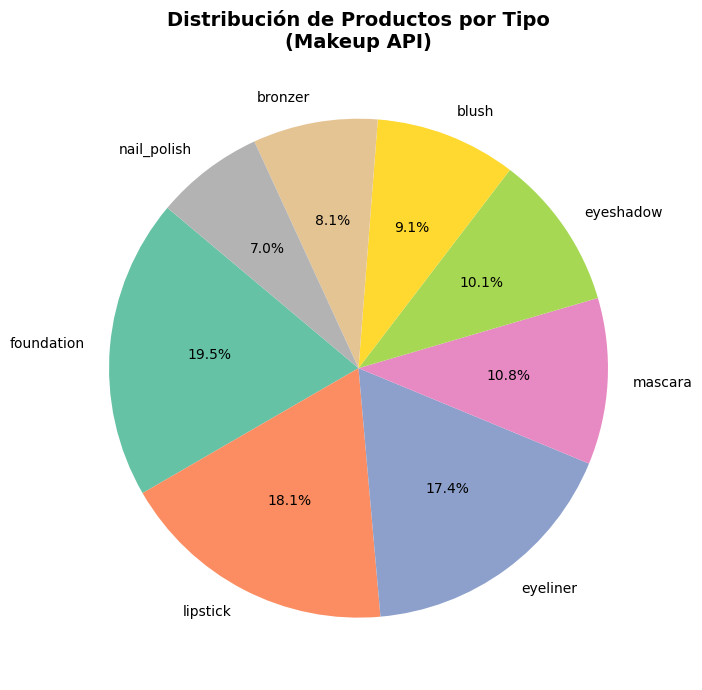

✅ Gráfico 1 - Torta guardado


In [13]:
# Celda 5: Gráfico de Torta - Distribución por tipo de producto
tipo_counts = df["product_type"].value_counts().head(8)

fig, ax = plt.subplots(figsize=(9, 7))
ax.pie(
    tipo_counts.values,
    labels=tipo_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("Set2", len(tipo_counts))
)
ax.set_title("Distribución de Productos por Tipo\n(Makeup API)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("grafico_torta.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 1 - Torta guardado")

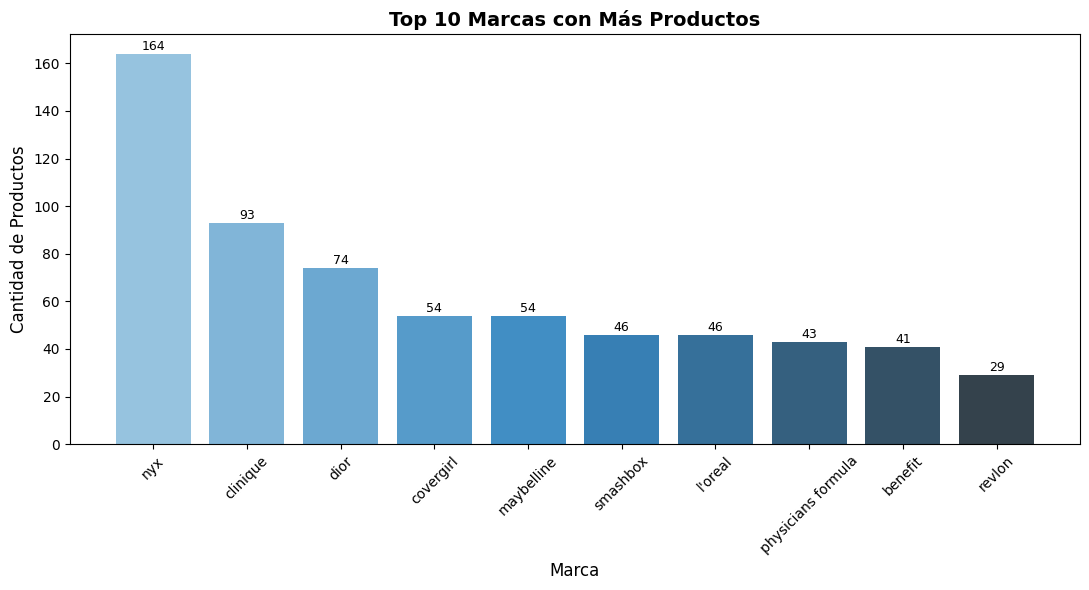

✅ Gráfico 2 - Barras guardado


In [14]:
# Celda 6: Gráfico de Barras - Top 10 marcas con más productos
top_marcas = df["brand"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(top_marcas.index, top_marcas.values,
              color=sns.color_palette("Blues_d", len(top_marcas)))
ax.set_title("Top 10 Marcas con Más Productos", fontsize=14, fontweight='bold')
ax.set_xlabel("Marca", fontsize=12)
ax.set_ylabel("Cantidad de Productos", fontsize=12)
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, top_marcas.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("grafico_barras.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 2 - Barras guardado")

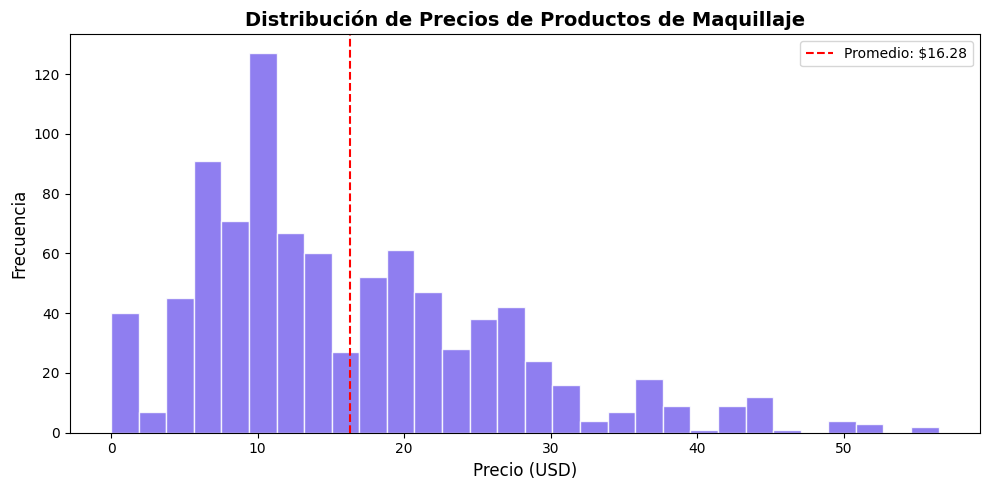

✅ Gráfico 3 - Histograma guardado


In [15]:
# Celda 7: Histograma - Distribución de precios
df_precio = df[df["price"].notna() & (df["price"] < 60)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_precio["price"], bins=30,
        color='mediumslateblue', edgecolor='white', alpha=0.85)
ax.set_title("Distribución de Precios de Productos de Maquillaje",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Precio (USD)", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.axvline(df_precio["price"].mean(), color='red', linestyle='--',
           label=f'Promedio: ${df_precio["price"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.savefig("grafico_histograma.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 3 - Histograma guardado")

In [16]:
# Celda 8: Resumen narrativo de los hallazgos
print(f"""
📊 INSIGHTS DESCUBIERTOS — Makeup API
======================================
1. El precio promedio es ${precio_prom:.2f} USD, mercado mayormente accesible.
2. La marca '{marca_top}' domina con {marca_count} productos en el catálogo.
3. El tipo '{tipo_top}' es el más común, reflejando alta demanda.
4. El rating promedio es {rating_prom:.2f}/5.0, satisfacción moderada-alta.
5. El producto más caro es '{prod_caro}' a ${precio_max:.2f}, hay segmento premium.
""")


📊 INSIGHTS DESCUBIERTOS — Makeup API
1. El precio promedio es $16.51 USD, mercado mayormente accesible.
2. La marca 'nyx' domina con 164 productos en el catálogo.
3. El tipo 'foundation' es el más común, reflejando alta demanda.
4. El rating promedio es 4.32/5.0, satisfacción moderada-alta.
5. El producto más caro es 'Dior Holiday Couture Collection' a $77.00, hay segmento premium.

